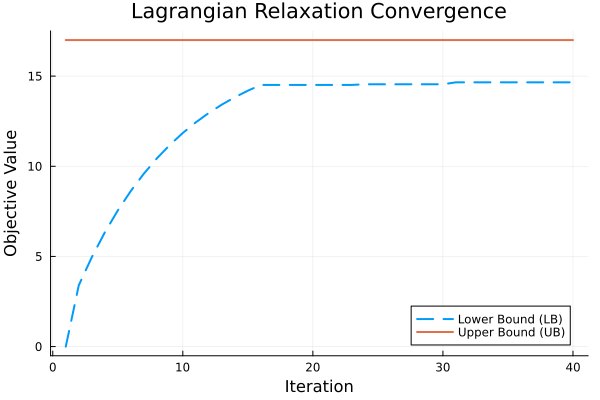

-------------- Starting Lagrangian Relaxation -------------
Iter. |    λ    |  Lower Bound  |   Upper Bound  |   Gap
-----------------------------------------------------------
    1 |  0.0000 |        0.0000 |        17.0000 |    17.000
    2 | 13.6000 |        3.4000 |        17.0000 |    13.600
    3 | 12.0457 |        4.9543 |        17.0000 |    12.046
    4 | 10.6691 |        6.3309 |        17.0000 |    10.669
    5 |  9.4497 |        7.5503 |        17.0000 |     9.450
    6 |  8.3698 |        8.6302 |        17.0000 |     8.370
    7 |  7.4132 |        9.5868 |        17.0000 |     7.413
    8 |  6.5660 |       10.4340 |        17.0000 |     6.566
    9 |  5.8156 |       11.1844 |        17.0000 |     5.816
   10 |  5.1510 |       11.8490 |        17.0000 |     5.151
   11 |  4.5623 |       12.4377 |        17.0000 |     4.562
   12 |  4.0409 |       12.9591 |        17.0000 |     4.041
   13 |  3.5791 |       13.4209 |        17.0000 |     3.579
   14 |  3.1700 |       13.830

In [2]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 7 – Lagrangian relaxation
#  Section: 7.2 - Simple Example
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP   # For mathematical programming
using HiGHS  # HiGHS solver
using Printf # For formatted output
using Plots  # For plotting

# Function to solve the original integer program exactly
function solve_exact()
    # Create the model
    model =  JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define binary variables
    @variable(model, x[1:2], Bin)
    # Define the objective function
    @objective(model, Min, 7 * x[1] + 10 * x[2])
    # Define the constraint
    @constraint(model, 3 * x[1] + 5 * x[2] >= 7)
    # Solve the model
    JuMP.optimize!(model)
    # Get results
    x_opt =  JuMP.value.(x)
    obj_value = JuMP.objective_value(model)
    return x_opt, obj_value
end

# Function to plot convergence of LB and UB
function plot_convergence(lb_history, ub_history)
    p = plot(1:length(lb_history), [lb_history ub_history],
        label=["Lower Bound (LB)" "Upper Bound (UB)"],
        xlabel="Iteration",
        ylabel="Objective Value",
        title="Lagrangian Relaxation Convergence",
        linewidth=2,
        linestyle=[:dash :solid],
        legend=:bottomright)
    display(p)
end

# Function to perform Lagrangian relaxation
function solve_lagrangian(iterations = 100)
    # Initialize variables
    x = [0, 0]  # Initial solution
    λ = 0.0     # Initial Lagrange multiplier
    λ_best = λ  # To track the best λ found
    α = 0.1     # Step size
    θ = 0.8     # A factor to update multiplier (Held-Karp)
    LB = -Inf   # Best lower bound found so far
    UB = Inf    # Best upper bound found so far
    LB_history = Float64[] # To store LB values for plotting
    UB_history = Float64[] # To store UB values for plotting

    # Logic to stop if no improvement in UB for a certain number of iterations
    no_improve_limit = 10
    no_improve_counter = 0

    println("-------------- Starting Lagrangian Relaxation -------------")
    println("Iter. |    λ    |  Lower Bound  |   Upper Bound  |   Gap")
    println("-"^59)

    for t in 1:iterations
        # Compute primal solution at current λ
        x[1] = (7 - 3 * λ) > 0 ? 1 : 0
        x[2] = (10 - 5 * λ) > 0 ? 1 : 0

        # Lagrangian dual value
        zL = 7 * λ + min(0, 7 - 3 * λ) + min(0, 10 - 5 * λ)

        # Check for improvement in LB
        if zL > LB 
            LB = zL
            λ_best = λ              # Update the best λ found
            no_improve_counter = 0  # Reset counter if we have an improvement
        else
            no_improve_counter += 1
            # Check if we have reached the limit of no improvement
            if no_improve_counter >= no_improve_limit
                println("-"^59)
                println("Lagrangian relaxation stopped. No improvement in LB for $no_improve_limit iterations.")
                break
            end
        end

        # Feasible primal value
        if 3 * x[1] + 5 * x[2] >= 7
            zP = 7 * x[1] + 10 * x[2]
            UB = min(UB, zP)
        end
        
        # Store LB and UB values for plotting
        push!(LB_history, LB)
        push!(UB_history, UB)

        # Print iteration details
        @printf("%5d | %7.4f | %13.4f | %14.4f | %9.3f\n", t, λ, LB, UB, UB - LB)

        # Subgradient
        g = 7 - 3 * x[1] - 5 * x[2]
        
        # Update step size (Diminishing step size)
        α = θ * ((UB - LB) / (g^2 + 1e-8))  # Adaptive step size based on Held-Karp
        
        # Update λ (project onto λ ≥ 0)
        λ = max(0, λ - α * g)
    end
    return LB, λ_best, LB_history, UB_history
end

# Solve using Lagrangian relaxation
LB, λ_best, LB_history, UB_history = solve_lagrangian()

# Solve exactly to find the optimal value
xO, zO = solve_exact()

println("------------------------- Results -------------------------")
@printf("Optimal Dual Solution (λ = %4.2f): %4.2f\n", λ_best, LB)
@printf("Optimal Primal Solution: x = [%d, %d] with objective value %4.2f\n", xO[1], xO[2], zO)
@printf("Duality gap: %4.2f - %4.2f = %4.2f\n", zO, LB, zO - LB)

# Plot convergence of LB and UB
plot_convergence(LB_history, UB_history)